# Part 1

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from PIL import Image

IMAGE_PATH = "selfie.jpg"

def load_grayscale(path):
    img = Image.open(path).convert("L")
    arr = np.asarray(img).astype(np.float32) / 255.0
    return arr

def show_image(img, title="", cmap="gray"):
    plt.figure(figsize=(5,5))
    plt.imshow(img, cmap=cmap)
    plt.title(title)
    plt.axis("off")
    plt.show()

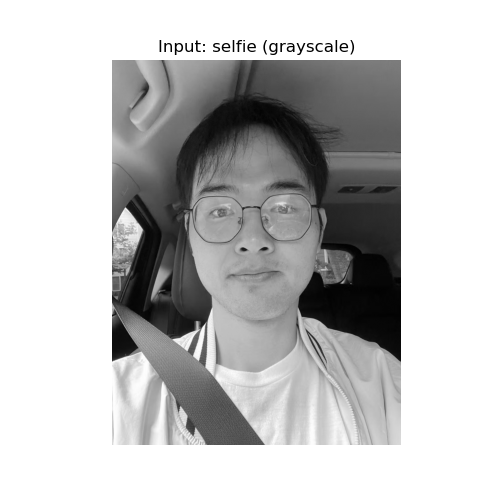

Image shape: (1706, 1279)


In [4]:
def pad_zero(img, pad_y, pad_x):
    H, W = img.shape[:2]
    out = np.zeros((H + 2*pad_y, W + 2*pad_x), dtype=img.dtype)
    out[pad_y:pad_y+H, pad_x:pad_x+W] = img
    return out

def conv2d_four_loops(img, kernel):
    H, W = img.shape
    kH, kW = kernel.shape
    k = np.flipud(np.fliplr(kernel))

    pad_y, pad_x = kH // 2, kW // 2
    padded = pad_zero(img, pad_y, pad_x)
    out = np.zeros_like(img, dtype=np.float32)

    for y in range(H):
        for x in range(W):
            acc = 0.0
            for i in range(kH):
                for j in range(kW):
                    acc += padded[y + i, x + j] * k[i, j]
            out[y, x] = acc
    return out

def conv2d_two_loops(img, kernel):
    H, W = img.shape
    kH, kW = kernel.shape
    k = np.flipud(np.fliplr(kernel))
    pad_y, pad_x = kH // 2, kW // 2
    padded = pad_zero(img, pad_y, pad_x)
    out = np.zeros_like(img, dtype=np.float32)

    for y in range(H):
        for x in range(W):
            window = padded[y:y+kH, x:x+kW]
            out[y, x] = np.sum(window * k)
    return out

img = load_grayscale(IMAGE_PATH)
show_image(img, "Input: selfie (grayscale)")
print("Image shape:", img.shape)


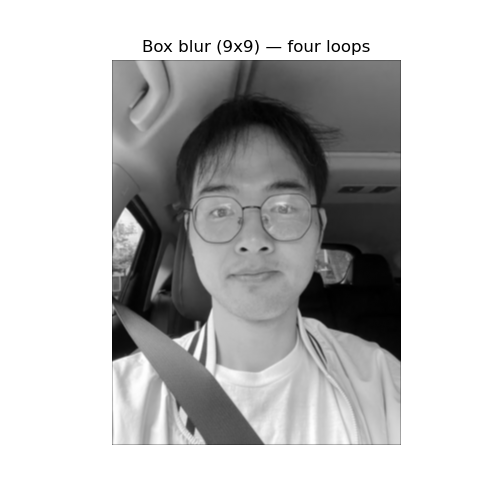

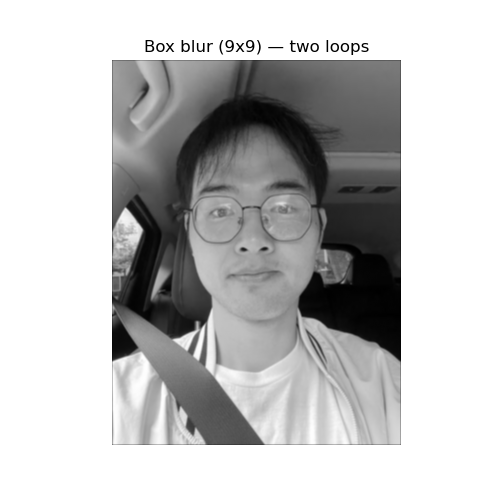

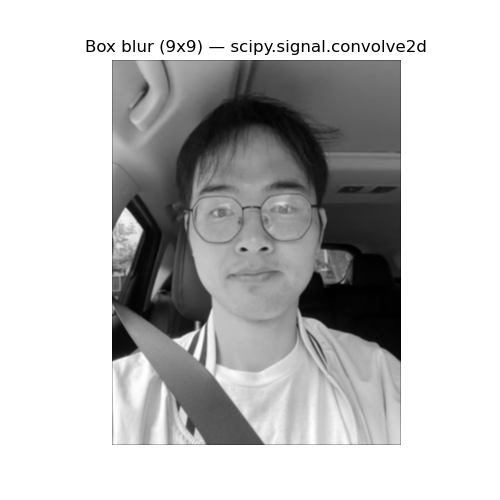

Max |four - scipy|: 1.7285347e-06
Max |two  - scipy|: 1.1920929e-06


In [5]:
box_size = 9
box_kernel = np.ones((box_size, box_size), dtype=np.float32) / (box_size * box_size)

blur_4 = conv2d_four_loops(img, box_kernel)
blur_2 = conv2d_two_loops(img, box_kernel)

blur_sp = signal.convolve2d(img, box_kernel, mode="same", boundary="fill", fillvalue=0)

show_image(blur_4, "Box blur (9x9) — four loops")
show_image(blur_2, "Box blur (9x9) — two loops")
show_image(blur_sp, "Box blur (9x9) — scipy.signal.convolve2d")

print("Max |four - scipy|:", np.max(np.abs(blur_4 - blur_sp)))
print("Max |two  - scipy|:", np.max(np.abs(blur_2 - blur_sp)))

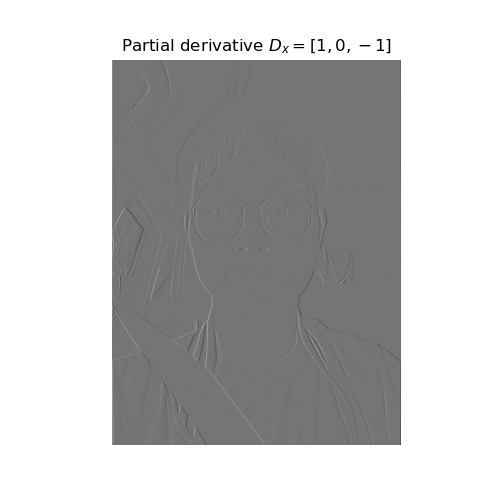

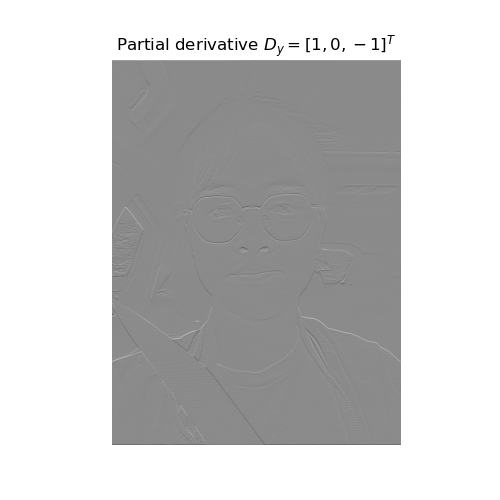

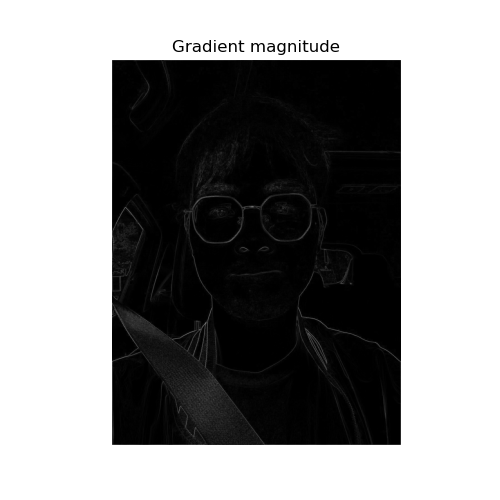

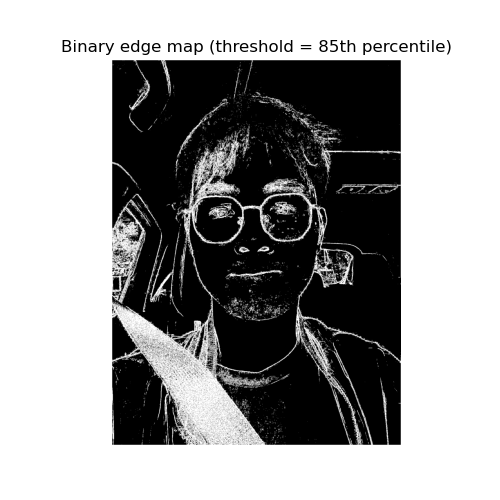

In [6]:
Dx = np.array([[1, 0, -1]], dtype=np.float32)
Dy = Dx.T

Ix = conv2d_two_loops(img, Dx)
Iy = conv2d_two_loops(img, Dy)

grad_mag = np.sqrt(Ix**2 + Iy**2)

percentile = 85
T = np.percentile(grad_mag, percentile)
edge_binary = (grad_mag >= T).astype(np.float32)

show_image(Ix, "Partial derivative $D_x = [1, 0, -1]$")
show_image(Iy, "Partial derivative $D_y = [1, 0, -1]^T$")
show_image(grad_mag, "Gradient magnitude")
show_image(edge_binary, f"Binary edge map (threshold = {percentile}th percentile)")

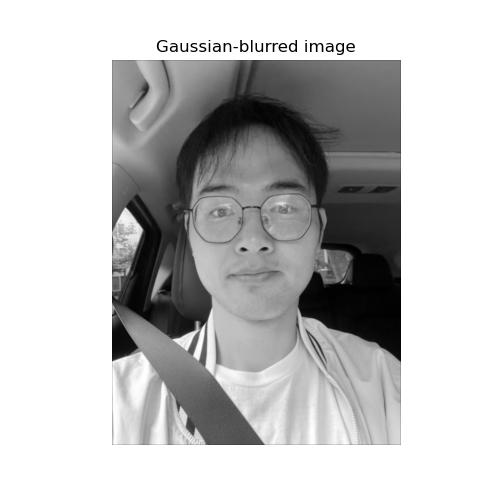

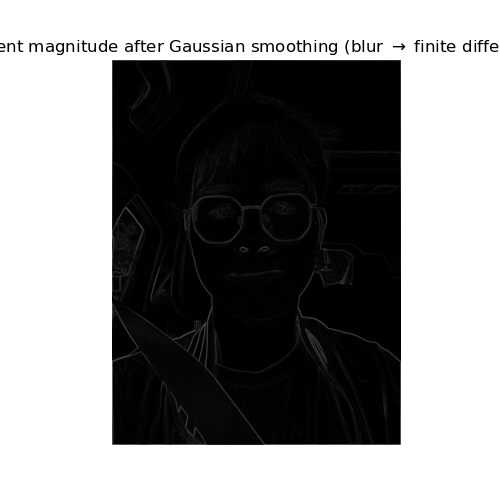

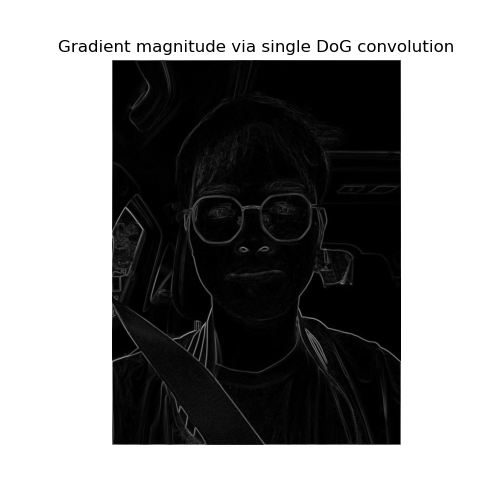

In [7]:
def gaussian_kernel(ksize=7, sigma=1.5):
    """Create a 2D Gaussian kernel of size (ksize x ksize) with standard deviation sigma.
    The kernel is normalized to sum to 1.
    """
    assert ksize % 2 == 1, "ksize should be odd"
    ax = np.arange(-(ksize//2), ksize//2 + 1, dtype=np.float32)
    xx, yy = np.meshgrid(ax, ax)
    kernel = np.exp(-(xx**2 + yy**2) / (2*sigma**2))
    kernel /= np.sum(kernel)
    return kernel

G = gaussian_kernel(ksize=9, sigma=1.6)
img_blur = conv2d_two_loops(img, G)
Ix_g = conv2d_two_loops(img_blur, Dx)
Iy_g = conv2d_two_loops(img_blur, Dy)
grad_mag_smooth = np.sqrt(Ix_g**2 + Iy_g**2)

Gx = signal.convolve2d(G, Dx, mode="full")
Gy = signal.convolve2d(G, Dy, mode="full")
Gx -= Gx.mean()
Gy -= Gy.mean()

Ix_dog = conv2d_two_loops(img, Gx)
Iy_dog = conv2d_two_loops(img, Gy)
grad_mag_dog = np.sqrt(Ix_dog**2 + Iy_dog**2)

show_image(img_blur, "Gaussian-blurred image")
show_image(grad_mag_smooth, "Gradient magnitude after Gaussian smoothing (blur $\\rightarrow$ finite differences)")
show_image(grad_mag_dog, "Gradient magnitude via single DoG convolution")

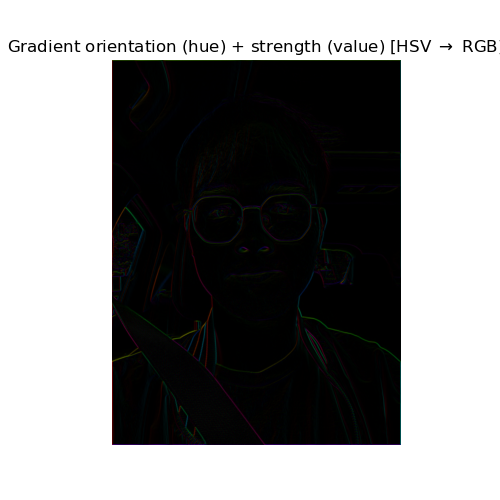

In [8]:
def orientation_hsv(Ix, Iy, mag=None):
    H, W = Ix.shape
    if mag is None:
        mag = np.sqrt(Ix**2 + Iy**2)

    angle = (np.arctan2(Iy, Ix) + 2*np.pi) % (2*np.pi)
    hue = angle / (2*np.pi)

    m = mag / (mag.max() + 1e-8)
    sat = np.ones_like(m)

    hsv = np.stack([hue, sat, m], axis=-1)

    def hsv_to_rgb(hsv):
        h, s, v = hsv[...,0], hsv[...,1], hsv[...,2]
        i = np.floor(h * 6).astype(int)
        f = h * 6 - i
        p = v * (1 - s)
        q = v * (1 - f * s)
        t = v * (1 - (1 - f) * s)
        i_mod = i % 6

        r = np.select([i_mod==0, i_mod==1, i_mod==2, i_mod==3, i_mod==4, i_mod==5],
                      [v, q, p, p, t, v], default=v)
        g = np.select([i_mod==0, i_mod==1, i_mod==2, i_mod==3, i_mod==4, i_mod==5],
                      [t, v, v, q, p, p], default=v)
        b = np.select([i_mod==0, i_mod==1, i_mod==2, i_mod==3, i_mod==4, i_mod==5],
                      [p, p, t, v, v, q], default=v)
        return np.stack([r,g,b], axis=-1)

    rgb = hsv_to_rgb(hsv)
    return np.clip(rgb, 0, 1)

orient_rgb = orientation_hsv(Ix_g, Iy_g, mag=grad_mag_smooth)
show_image(orient_rgb, "Gradient orientation (hue) + strength (value) [HSV $\\rightarrow$ RGB]", cmap=None)

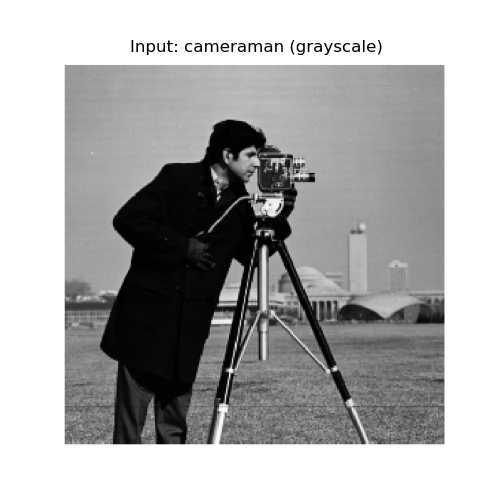

Image shape: (542, 540)


In [9]:
IMAGE_PATH = "cameraman.png"

img = load_grayscale(IMAGE_PATH)
show_image(img, "Input: cameraman (grayscale)")
print("Image shape:", img.shape)

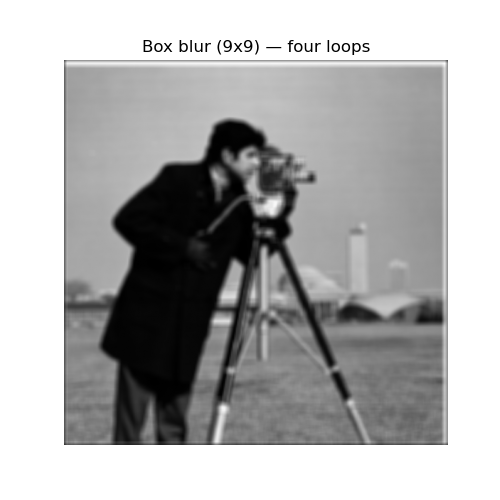

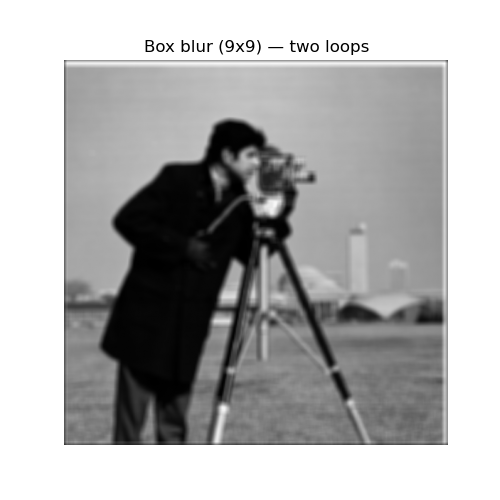

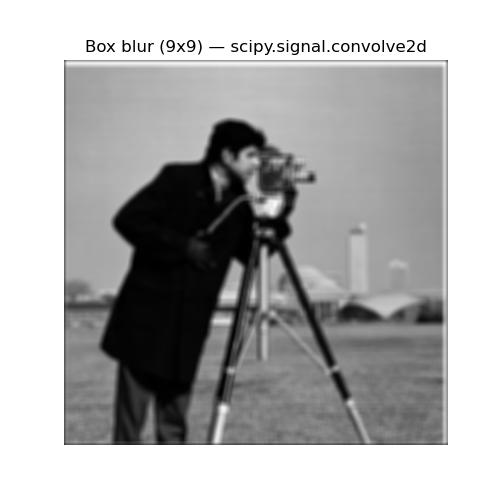

Max |four - scipy|: 8.940697e-07
Max |two  - scipy|: 7.748604e-07


In [10]:
blur_4 = conv2d_four_loops(img, box_kernel)
blur_2 = conv2d_two_loops(img, box_kernel)

blur_sp = signal.convolve2d(img, box_kernel, mode="same", boundary="fill", fillvalue=0)

show_image(blur_4, "Box blur (9x9) — four loops")
show_image(blur_2, "Box blur (9x9) — two loops")
show_image(blur_sp, "Box blur (9x9) — scipy.signal.convolve2d")

print("Max |four - scipy|:", np.max(np.abs(blur_4 - blur_sp)))
print("Max |two  - scipy|:", np.max(np.abs(blur_2 - blur_sp)))

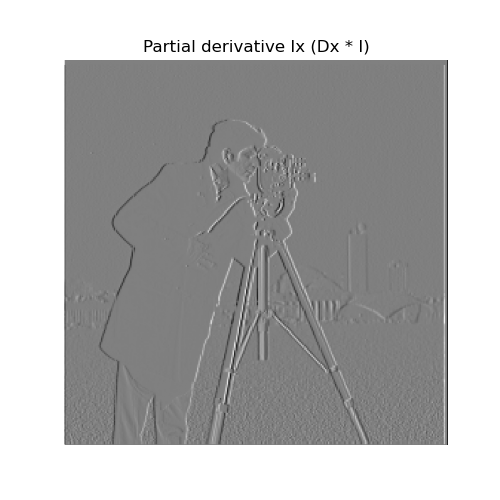

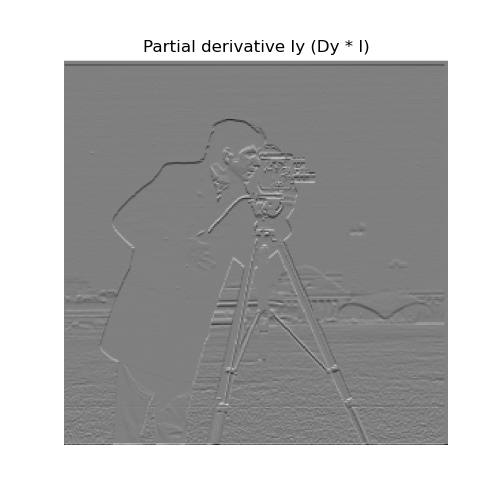

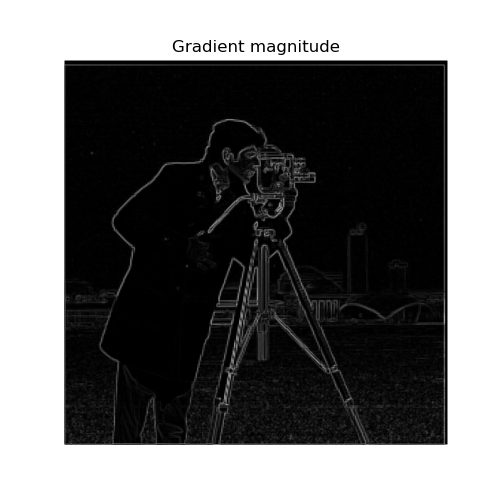

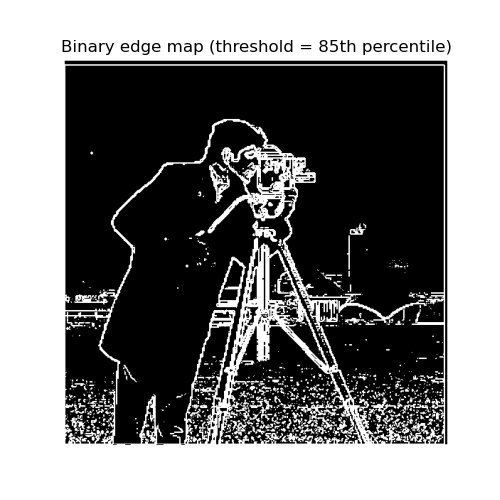

In [11]:
Ix = conv2d_two_loops(img, Dx)
Iy = conv2d_two_loops(img, Dy)

grad_mag = np.sqrt(Ix**2 + Iy**2)

percentile = 85
T = np.percentile(grad_mag, percentile)
edge_binary = (grad_mag >= T).astype(np.float32)

show_image(Ix, "Partial derivative Ix (Dx * I)")
show_image(Iy, "Partial derivative Iy (Dy * I)")
show_image(grad_mag, "Gradient magnitude")
show_image(edge_binary, f"Binary edge map (threshold = {percentile}th percentile)")

/tmp/ipykernel_22088/1978599053.py:14: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize=(5,5))


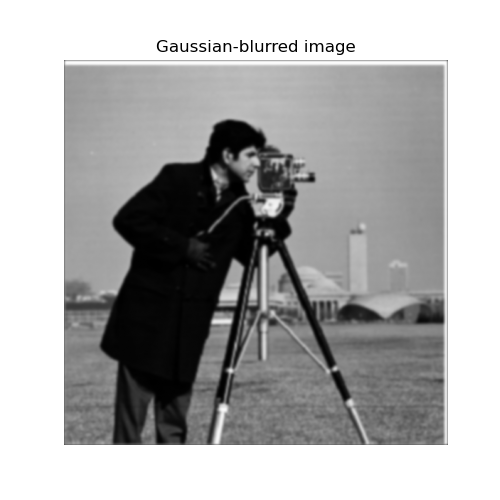

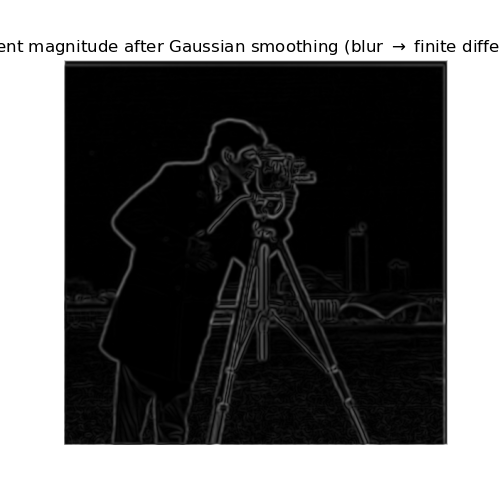

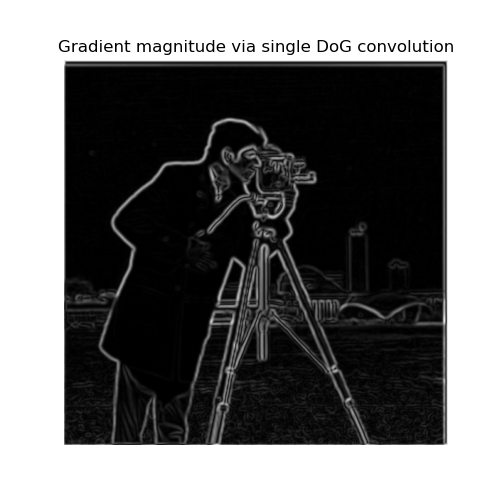

In [12]:
img_blur = conv2d_two_loops(img, G)
Ix_g = conv2d_two_loops(img_blur, Dx)
Iy_g = conv2d_two_loops(img_blur, Dy)
grad_mag_smooth = np.sqrt(Ix_g**2 + Iy_g**2)

Gx = signal.convolve2d(G, Dx, mode="full")
Gy = signal.convolve2d(G, Dy, mode="full")
Gx -= Gx.mean()
Gy -= Gy.mean()

Ix_dog = conv2d_two_loops(img, Gx)
Iy_dog = conv2d_two_loops(img, Gy)
grad_mag_dog = np.sqrt(Ix_dog**2 + Iy_dog**2)

show_image(img_blur, "Gaussian-blurred image")
show_image(grad_mag_smooth, "Gradient magnitude after Gaussian smoothing (blur $\\rightarrow$ finite differences)")
show_image(grad_mag_dog, "Gradient magnitude via single DoG convolution")


# Part 2

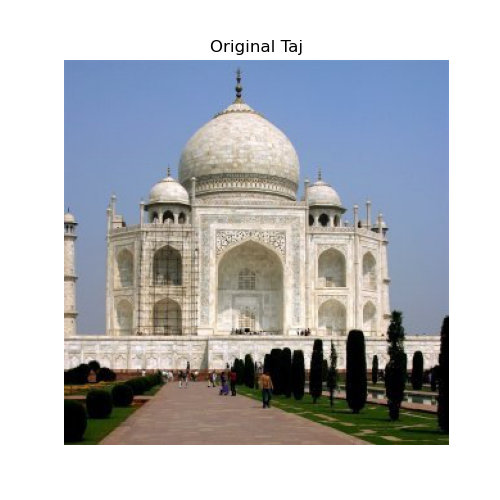

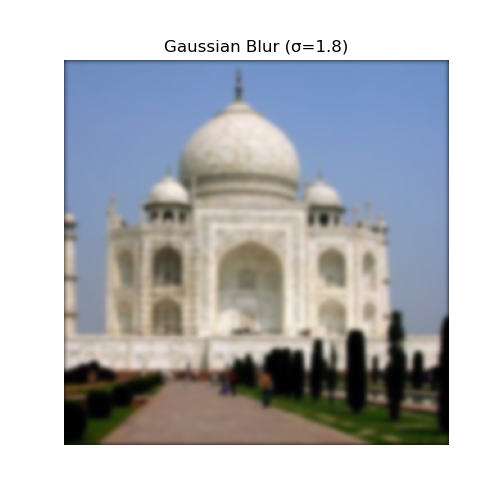

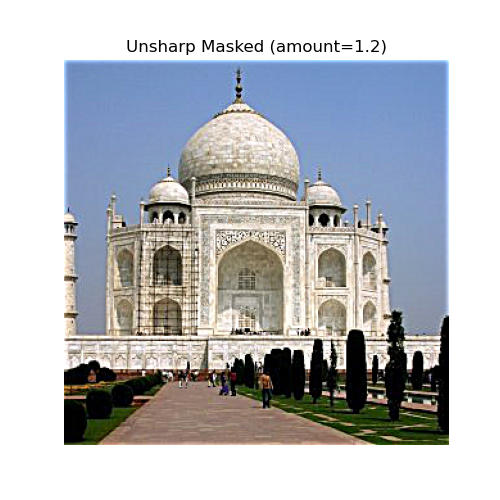

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.6690115..1.5989659].


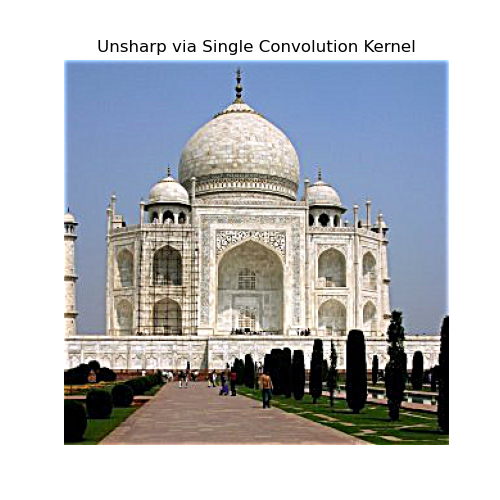

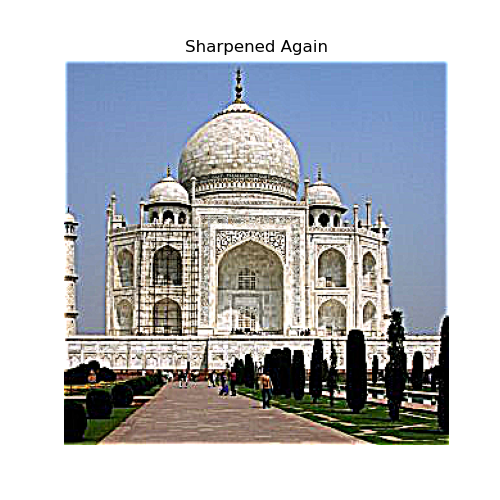

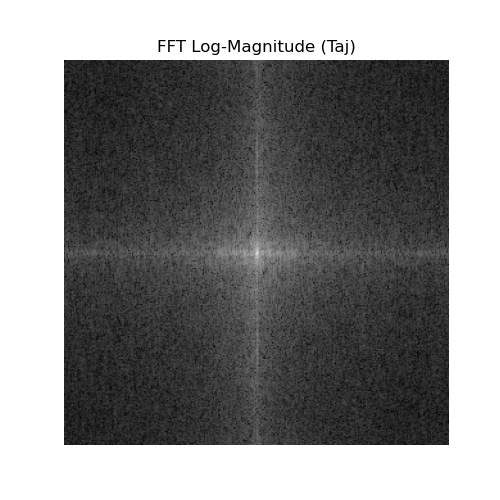

In [13]:
def imread_rgb01(path):
    return np.asarray(Image.open(path).convert("RGB")).astype(np.float32) / 255.0

def apply_kernel(img, kernel):
    if img.ndim == 2:
        return conv2d_two_loops(img, kernel)
    out = np.zeros_like(img, dtype=np.float32)
    for c in range(img.shape[2]):
        out[..., c] = conv2d_two_loops(img[..., c], kernel)
    return out

def to_gray(img):
    if img.ndim == 2:
        return img
    r,g,b = img[...,0], img[...,1], img[...,2]
    return 0.2989*r + 0.5870*g + 0.1140*b

def unsharp_mask(img, sigma=1.8, amount=1.2, ksize=None):
    if ksize is None:
        ksize = int(np.ceil(6*sigma)) | 1
    G = gaussian_kernel(ksize=ksize, sigma=sigma)
    blurred = apply_kernel(img, G)
    sharp = (1+amount)*img - amount*blurred
    return np.clip(sharp, 0, 1), blurred

def unsharp_single_kernel(sigma=1.8, amount=1.2, ksize=None):
    if ksize is None:
        ksize = int(np.ceil(6*sigma)) | 1
    G = gaussian_kernel(ksize=ksize, sigma=sigma)
    K = -amount * G
    K[ksize//2, ksize//2] += (1 + amount)
    return K

TAJ_PATH = "building.jpg"
taj = imread_rgb01(TAJ_PATH)

sharp, taj_blur = unsharp_mask(taj, sigma=1.8, amount=1.2)
show_image(taj, "Original Taj")
show_image(taj_blur, "Gaussian Blur (σ=1.8)")
show_image(sharp, "Unsharp Masked (amount=1.2)")

K = unsharp_single_kernel(sigma=1.8, amount=1.2)
taj_sharp_one = apply_kernel(taj, K)
show_image(taj_sharp_one, "Unsharp via Single Convolution Kernel")

sharp_again, _ = unsharp_mask(sharp, sigma=1.8, amount=1.2)
show_image(sharp_again, "Sharpened Again")


def fft_log_mag(gray_or_rgb):
    g = to_gray(gray_or_rgb)
    F = np.fft.fft2(g)
    F = np.fft.fftshift(F)
    mag = np.log1p(np.abs(F))
    mag /= mag.max() + 1e-8
    return mag

show_image(fft_log_mag(taj), "FFT Log-Magnitude (Taj)")